In [98]:
import numpy as np 
import pandas as pd 

In [99]:
def build_transition_matrix(adj_matrix):
    """
    Converts a given adjacency matrix into a transition matrix for a Markov chain.
    Rows are normalized to sum to 1.

    Parameters:
        adj_matrix (np.ndarray): Weighted adjacency matrix (n x n).

    Returns:
        np.ndarray: Transition matrix (n x n).
    """
    row_sums = adj_matrix.sum(axis=1)
    # Avoid division by zero for disconnected vertices
    transition_matrix = np.divide(
        adj_matrix, 
        row_sums[:, np.newaxis], 
        where=row_sums[:, np.newaxis] != 0
    )
    return transition_matrix


In [100]:
adj_matrix = pd.read_csv('muscle_to_muscle.csv')

In [101]:
subset_size = 60
test_subset = adj_matrix.iloc[:subset_size, :subset_size]

In [61]:
P = build_transition_matrix(test_subset.values)

In [62]:
P.shape

(60, 60)

In [63]:
def generate_current_dictionary(transition_matrix, source, sink):
    """
    Generates a dictionary of current flow values for each edge in the graph.

    Parameters:
        transition_matrix (np.ndarray): Transition matrix (n x n).
        source (int): Source node index.
        sink (int): Sink node index.

    Returns:
        dict: Dictionary of current flow values for each edge in the graph.
    """
    unit_vec = np.zeros(transition_matrix.shape[0])
    #for source index set +1, for sink index set -1
    unit_vec[source] = 1
    unit_vec[sink] = -1 
    Q =np.delete(np.delete(transition_matrix, sink, 0), sink, 1)
    #get diagonal matrix which is sum of degree for each index . 
    #basically in transition matrix , if we sum each row we get degree of that index
    D = np.diag(np.sum(transition_matrix, axis=1))
    Ddash = np.delete(np.delete(D, sink, 0), sink, 1)
    Diff = Ddash - Q 
    #get inverse of Diff matrix
    Diff_inv = np.linalg.inv(Diff) 
    #now add a row and column full of zeros at the sink index in Diff_inv
    Diff_inv = np.insert(Diff_inv, sink, 0, axis=0)
    Diff_inv = np.insert(Diff_inv, sink, 0, axis=1)

    #get the current flow values
    current = np.dot(Diff_inv, unit_vec)
    return current 

In [64]:
#we need a current_dictionary for each source and sink pair.
current_dict = {}
for source in range(P.shape[0]):
    for sink in range(source+1,P.shape[0]):
        current_dict[(source,sink)] = generate_current_dictionary(P, source, sink)

In [65]:
#we now have the current_dictionary, that we wanted for each vertex, wrto every other pair. Now it is time to get the min_cut fraction w.r.to each pair.

In [102]:
np_adjacency = test_subset.values

In [103]:
np_adjacency_remove_self = np_adjacency - np.diag(np.diag(np_adjacency))

In [104]:
np_adjacency_remove_self.shape

(60, 60)

In [105]:
from collections import deque, defaultdict

In [106]:
def bfs(capacity, flow, s, t, parent):
    visited = [False] * len(capacity)
    queue = deque([s])
    visited[s] = True
    while queue:
        u = queue.popleft()
        for v in range(len(capacity)):
            if not visited[v] and capacity[u][v] - flow[u][v] > 0:
                queue.append(v)
                visited[v] = True
                parent[v] = u
                if v == t:
                    return True
    return False

In [107]:
def edmonds_karp(capacity, s, t):
    n = len(capacity)
    flow = [[0] * n for _ in range(n)]
    parent = [-1] * n
    max_flow = 0

    while bfs(capacity, flow, s, t, parent):
        path_flow = float('Inf')
        v = t
        while v != s:
            u = parent[v]
            path_flow = min(path_flow, capacity[u][v] - flow[u][v])
            v = u

        v = t
        while v != s:
            u = parent[v]
            flow[u][v] += path_flow
            flow[v][u] -= path_flow
            v = u

        max_flow += path_flow

    return max_flow, flow

In [108]:
def find_min_cut_edges(capacity, flow, s):
    n = len(capacity)
    visited = [False] * n
    queue = deque([s])
    visited[s] = True

    while queue:
        u = queue.popleft()
        for v in range(n):
            if not visited[v] and capacity[u][v] - flow[u][v] > 0:
                visited[v] = True
                queue.append(v)

    # Min-cut edges
    min_cut = []
    for u in range(n):
        for v in range(n):
            if visited[u] and not visited[v] and capacity[u][v] > 0:
                min_cut.append((u, v))
    return min_cut

In [109]:
def all_pairs_min_cut(adjacency_matrix):
    n = len(adjacency_matrix)
    results = {}

    for s in range(n):
        for t in range(s + 1, n):
            # Initialize capacity
            capacity = [[adjacency_matrix[i][j] for j in range(n)] for i in range(n)]
            _, flow = edmonds_karp(capacity, s, t)
            min_cut = find_min_cut_edges(capacity, flow, s)
            results[(s, t)] = min_cut

    return results

In [73]:
min_cut_dictionary = all_pairs_min_cut(P)

In [110]:
min_cut_dictionary_self_removed = all_pairs_min_cut(np_adjacency_remove_self)

In [119]:
min_cut_dictionary_self_removed

{(0, 1): [(0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (0, 5),
  (0, 6),
  (0, 7),
  (0, 8),
  (0, 9),
  (0, 10),
  (0, 11),
  (0, 12),
  (0, 13),
  (0, 14),
  (0, 15),
  (0, 16),
  (0, 17),
  (0, 18),
  (0, 19),
  (0, 20),
  (0, 21),
  (0, 22),
  (0, 23),
  (0, 24),
  (0, 25),
  (0, 26),
  (0, 27),
  (0, 28),
  (0, 29),
  (0, 30),
  (0, 31),
  (0, 32),
  (0, 33),
  (0, 34),
  (0, 35),
  (0, 36),
  (0, 37),
  (0, 38),
  (0, 39),
  (0, 40),
  (0, 41),
  (0, 42),
  (0, 43),
  (0, 44),
  (0, 45),
  (0, 46),
  (0, 47),
  (0, 48),
  (0, 49),
  (0, 50),
  (0, 51),
  (0, 52),
  (0, 53),
  (0, 54),
  (0, 55),
  (0, 56),
  (0, 57),
  (0, 58),
  (0, 59)],
 (0, 2): [(0, 2),
  (1, 2),
  (3, 2),
  (4, 2),
  (5, 2),
  (6, 2),
  (7, 2),
  (8, 2),
  (9, 2),
  (10, 2),
  (11, 2),
  (12, 2),
  (13, 2),
  (14, 2),
  (15, 2),
  (16, 2),
  (17, 2),
  (18, 2),
  (19, 2),
  (20, 2),
  (21, 2),
  (22, 2),
  (23, 2),
  (24, 2),
  (25, 2),
  (26, 2),
  (27, 2),
  (28, 2),
  (29, 2),
  (30, 2),
  (31, 2),
  (32, 2),


In [120]:
#can you randomly , symmetrically set some values to 0 in the adjacency matrix and check if the min_cut_fraction is still the same?
np_adjacency_remove_self_random = np_adjacency_remove_self.copy()
np_adjacency_remove_self_random[np.random.choice([True, False], size=np_adjacency_remove_self_random.shape, p=[0.5, 0.5])] = 0

In [121]:
#i want you to set i,j and j,i to 0 if i,j is 0
for i in range(np_adjacency_remove_self_random.shape[0]):
    for j in range(np_adjacency_remove_self_random.shape[1]):
        if np_adjacency_remove_self_random[i][j] == 0:
            np_adjacency_remove_self_random[j][i] = 0

In [122]:
#is this syymentric?
np.all(np_adjacency_remove_self_random == np_adjacency_remove_self_random.T)

True

In [124]:
np_adjacency_remove_self_random.shape

(60, 60)

In [149]:
#for non zero_invert the matrix aij = 1/aij 
np_adjacency_remove_self_random_inverted = np_adjacency_remove_self_random.copy()
np_adjacency_remove_self_random_inverted[np_adjacency_remove_self_random != 0] = 1/np_adjacency_remove_self_random[np_adjacency_remove_self_random != 0]


In [150]:
#normalise inverted row wise 
row_sums = np_adjacency_remove_self_random_inverted.sum(axis=1)
np_adjacency_remove_self_random_inverted = np.divide(
    np_adjacency_remove_self_random_inverted, 
    row_sums[:, np.newaxis], 
    where=row_sums[:, np.newaxis] != 0
)

In [125]:
min_cut_dictionary_self_removed_random = all_pairs_min_cut(np_adjacency_remove_self_random)

In [126]:
min_cut_dictionary_self_removed_random

{(0, 1): [(8, 1),
  (12, 1),
  (13, 1),
  (16, 1),
  (28, 1),
  (33, 1),
  (34, 1),
  (36, 1),
  (46, 1),
  (49, 1),
  (51, 1),
  (58, 1),
  (59, 1)],
 (0, 2): [(3, 2),
  (7, 2),
  (9, 2),
  (21, 2),
  (22, 2),
  (26, 2),
  (28, 2),
  (29, 2),
  (30, 2),
  (33, 2),
  (34, 2),
  (40, 2),
  (52, 2),
  (54, 2)],
 (0, 3): [(0, 6),
  (0, 7),
  (0, 9),
  (0, 13),
  (0, 15),
  (0, 17),
  (0, 24),
  (0, 34),
  (0, 35),
  (0, 37),
  (0, 39),
  (0, 41),
  (0, 42),
  (0, 46),
  (0, 59)],
 (0, 4): [(0, 6),
  (0, 7),
  (0, 9),
  (0, 13),
  (0, 15),
  (0, 17),
  (0, 24),
  (0, 34),
  (0, 35),
  (0, 37),
  (0, 39),
  (0, 41),
  (0, 42),
  (0, 46),
  (0, 59)],
 (0, 5): [(13, 5),
  (14, 5),
  (15, 5),
  (16, 5),
  (19, 5),
  (24, 5),
  (25, 5),
  (28, 5),
  (32, 5),
  (33, 5),
  (43, 5),
  (45, 5),
  (49, 5),
  (54, 5),
  (56, 5)],
 (0, 6): [(0, 6),
  (3, 6),
  (12, 6),
  (18, 6),
  (31, 6),
  (33, 6),
  (38, 6),
  (41, 6),
  (44, 6)],
 (0, 7): [(0, 6),
  (0, 7),
  (0, 9),
  (0, 13),
  (0, 15),
  (0, 1

In [127]:
len(min_cut_dictionary_self_removed_random)

1770

In [128]:
current_dict_self_removed_random = {}
for source in range(P.shape[0]):
    for sink in range(source+1,P.shape[0]):
        current_dict_self_removed_random[(source,sink)] = generate_current_dictionary(np_adjacency_remove_self_random, source, sink)

In [129]:
def generate_fraction_dictionary_mincut(min_cut_dictionary,num_vertices):
    """
    Generates a dictionary of min-cut fractions for each edge in the graph.

    Parameters:
        min_cut_dictionary (dict): Dictionary of min-cut edges for each source-sink pair.

    Returns:
        dict: Dictionary of min-cut fractions for each edge in the graph.
    """
    fraction_dict = {}
    for key, value in min_cut_dictionary.items():
        source, sink = key
        temp_dict = {}
        num_edges = len(value)
        for vertex in range(num_vertices):
            temp_dict[vertex] = 0
        for edge in value:
            temp_dict[edge[0]] += (1/num_edges)
            temp_dict[edge[1]] += (1/num_edges)
        fraction_dict[key] = temp_dict
    return fraction_dict

In [130]:
fraction_dictionary_self_random = generate_fraction_dictionary_mincut(min_cut_dictionary_self_removed_random,60)

In [131]:
def custom_centrality_metric(current_dict, fraction_dict, num_vertices):

    """
    Computes a custom centrality metric for each edge in the graph.

    Parameters:
        current_dict (dict): Dictionary of current flow values for each edge.
        fraction_dict (dict): Dictionary of min-cut fractions for each edge.

    Returns:
        dict: Dictionary of custom centrality metric for each edge in the graph.
    """
    metric_dict = {}
    for source in range(num_vertices):
        for sink in range(source+1,num_vertices):
            key = (source,sink)
            temp_dict = {}
            for vertex in range(num_vertices):
                temp_dict[vertex] = current_dict[key][vertex] *np.exp(fraction_dict[key][vertex])
            metric_dict[key] = temp_dict    
    return metric_dict

In [132]:
def get_centrality_score(metric_dict,num_vertices):
    answer_dict = {}
    for vertex in range(num_vertices):
        answer_dict[vertex] = 0
    for key, value in metric_dict.items():
        for vertex in range(num_vertices):
            answer_dict[vertex] += (value[vertex]/sum(value.values()))
    return answer_dict
    

In [133]:
metric_dict_self_removed_random = custom_centrality_metric(current_dict_self_removed_random, fraction_dictionary_self_random, 60)

In [134]:
centrality_dict_self_removed_random = get_centrality_score(metric_dict_self_removed_random, 60)

In [135]:
sum_of_centrality = sum(centrality_dict_self_removed_random.values())
centrality_dict_self_removed_random_normalized = {k: v/sum_of_centrality for k, v in centrality_dict_self_removed_random.items()}

In [136]:
import json




In [137]:
centrality_dict_self_removed_random_normalized

with open('centrality_dict_self_removed_random_normalised_60cross60_REGULR_NORMALISED_.json', 'w') as f:
    json.dump(centrality_dict_self_removed_random_normalized, f)

Text(0.5, 1.0, 'Centrality Scores')

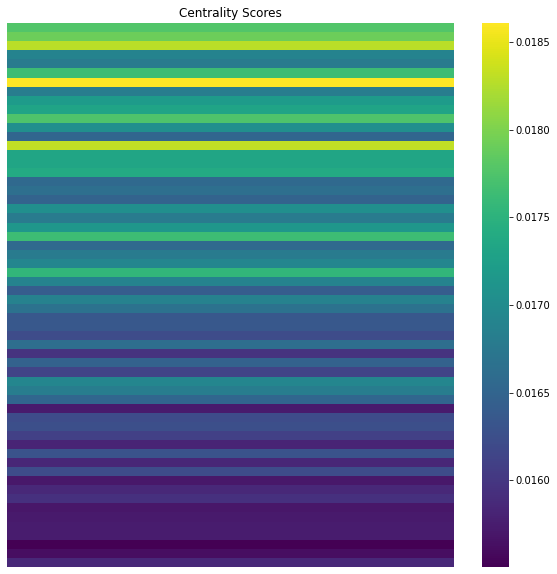

In [138]:
#heat_map of the centrality scores
import seaborn as sns
import matplotlib.pyplot as plt

centrality_df = pd.DataFrame(centrality_dict_self_removed_random_normalized.items(), columns=['Vertex', 'Centrality Score'])
centrality_df = centrality_df.sort_values(by='Vertex')
centrality_df = centrality_df.reset_index(drop=True)

centrality_matrix = np.zeros((60, 60))
for i in range(60):
    centrality_matrix[i] = centrality_df['Centrality Score'][i]

plt.figure(figsize=(10, 10))
sns.heatmap(centrality_matrix, cmap='viridis', annot=False, fmt='.2f', xticklabels=False, yticklabels=False)
plt.title('Centrality Scores')

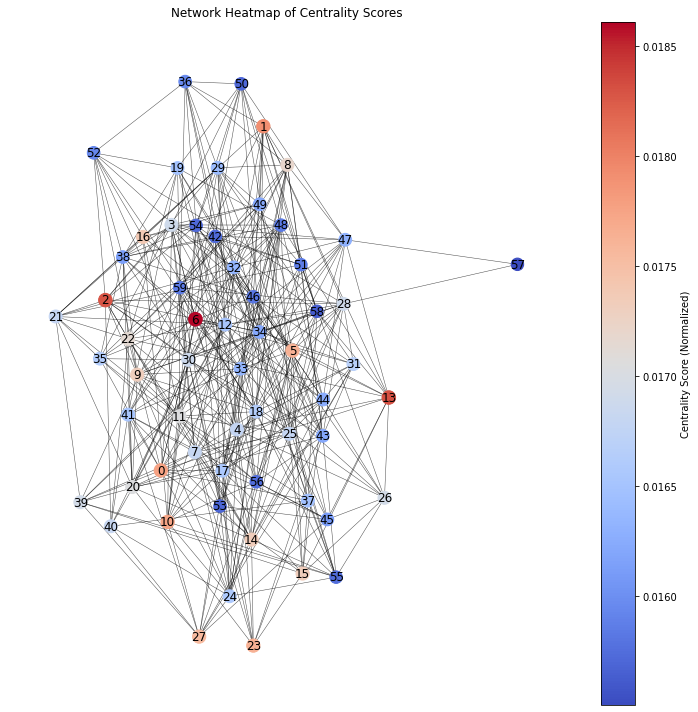

In [148]:
#can we plot this differently? like nodes on a plane and the size of the node is proportional to the centrality score?
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm  # for colormaps

# Assuming np_adjacency_remove_self_random is your adjacency matrix with self-loops removed and random weights
# Assuming centrality_dict_self_removed_random_normalized is your dictionary of normalized centrality scores for nodes

G = nx.from_numpy_array(np_adjacency_remove_self_random)
pos = nx.spring_layout(G)  # Use spring layout for node positioning

# Extract node values for heatmap
node_values = [centrality_dict_self_removed_random_normalized[v] for v in G.nodes()] 

# Create the heatmap
plt.figure(figsize=(10, 10))

# Choose a colormap (options: 'viridis', 'plasma', 'coolwarm', etc.)
cmap = cm.coolwarm  # Choose a colormap that suits your needs

# Create the node size list with scaling
node_size = [v * 10000 for v in node_values]  # Adjust scaling factor as needed


# Draw the graph with heatmap
nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(), node_color=node_values, cmap=cmap, node_size=node_size)
nx.draw_networkx_edges(G, pos, alpha=0.7, width=0.5)

# Add labels to nodes (optional)
nx.draw_networkx_labels(G, pos)

# Create a custom legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(node_values), vmax=max(node_values)))
sm.set_array([])
plt.colorbar(sm, label='Centrality Score (Normalized)')

plt.title('Network Heatmap of Centrality Scores')
plt.axis('off')
plt.tight_layout()
plt.show()

In [155]:
#now let's do betweenness for the same adjacency matrix
adj = np_adjacency_remove_self_random
n = adj.shape[0]
betweenness_centralities = np.zeros(n)

for s in range(n):
    stack = []
    pred = {i: [] for i in range(n)}
    sigma = {i: 0 for i in range(n)}
    sigma[s] = 1
    dist = {i: -1 for i in range(n)}
    dist[s] = 0
    queue = [s]
    while queue:
        v = queue.pop(0)
        stack.append(v)
        for w in range(n):
            if adj[v][w] > 0:
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)
    delta = {i: 0 for i in range(n)}
    while stack:
        w = stack.pop()
        for v in pred[w]:
            delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
        if w != s:
            betweenness_centralities[w] += delta[w]

betweenness_centralities = {i: betweenness_centralities[i] for i in range(n)}
sum_of_betweenness = sum(betweenness_centralities.values())
betweenness_centralities_normalized = {k: v/sum_of_betweenness for k, v in betweenness_centralities.items()}
betweenness_centralities_normalized

{0: 0.021031615661325092,
 1: 0.01345196428776683,
 2: 0.018559267703556932,
 3: 0.02267974364062393,
 4: 0.01898218894800997,
 5: 0.025266205449307143,
 6: 0.004548612388470401,
 7: 0.02306426324313936,
 8: 0.01568951174035237,
 9: 0.01551149593664729,
 10: 0.014074837797130367,
 11: 0.019011998372292005,
 12: 0.020073507025049318,
 13: 0.014421180608664552,
 14: 0.017373888518345124,
 15: 0.007478328431900769,
 16: 0.0061236875457970725,
 17: 0.028393120903098923,
 18: 0.027574664238516997,
 19: 0.00885213368538873,
 20: 0.01162751182956373,
 21: 0.013704447837590603,
 22: 0.01643597524846681,
 23: 0.006737994077271548,
 24: 0.02054559219121133,
 25: 0.015034478369050013,
 26: 0.01026208502126304,
 27: 0.011609042607097716,
 28: 0.03398152943714183,
 29: 0.017981045464555992,
 30: 0.0235437637984914,
 31: 0.009768569966029133,
 32: 0.02120788197503252,
 33: 0.03657014809693793,
 34: 0.044858018354061426,
 35: 0.007249269090625278,
 36: 0.006939473298550286,
 37: 0.011632068336875015,

In [152]:
#can you count for each pair, among all possible shortest paths, how many of them are greedy paths?
#choosing the min_value_edge at each step
#this is the fraction of greedy paths among all shortest paths

def generate_greedy_fraction_dictionary(adjacency_matrix):
    """
    Generates a dictionary of greedy fractions for each edge in the graph.

    Parameters:
        adjacency_matrix (np.ndarray): Adjacency matrix (n x n).

    Returns:
        dict: Dictionary of greedy fractions for each edge in the graph.
    """
    n = len(adjacency_matrix)
    results = {}
    for s in range(n):
        for t in range(s + 1, n):
            # Initialize capacity
            capacity = [[adjacency_matrix[i][j] for j in range(n)] for i in range(n)]
            _, flow = edmonds_karp(capacity, s, t)
            min_cut = find_min_cut_edges(capacity, flow, s)
            greedy_paths = 0
            for edge in min_cut:
                if edge[0] == s or edge[1] == s:
                    greedy_paths += 1
            results[(s, t)] = greedy_paths / len(min_cut)
    return results

greedy_fraction_dictionary = generate_greedy_fraction_dictionary(np_adjacency_remove_self_random)

greedy_fraction_dictionary



{(0, 1): 0.0,
 (0, 2): 0.0,
 (0, 3): 1.0,
 (0, 4): 1.0,
 (0, 5): 0.0,
 (0, 6): 0.1111111111111111,
 (0, 7): 1.0,
 (0, 8): 0.0,
 (0, 9): 1.0,
 (0, 10): 0.0,
 (0, 11): 1.0,
 (0, 12): 1.0,
 (0, 13): 0.08333333333333333,
 (0, 14): 0.0,
 (0, 15): 1.0,
 (0, 16): 0.0,
 (0, 17): 1.0,
 (0, 18): 1.0,
 (0, 19): 1.0,
 (0, 20): 0.0,
 (0, 21): 1.0,
 (0, 22): 0.0,
 (0, 23): 0.0,
 (0, 24): 1.0,
 (0, 25): 1.0,
 (0, 26): 0.0,
 (0, 27): 0.0,
 (0, 28): 1.0,
 (0, 29): 1.0,
 (0, 30): 0.0,
 (0, 31): 0.0,
 (0, 32): 1.0,
 (0, 33): 1.0,
 (0, 34): 1.0,
 (0, 35): 0.1,
 (0, 36): 1.0,
 (0, 37): 0.1,
 (0, 38): 1.0,
 (0, 39): 0.1,
 (0, 40): 0.0,
 (0, 41): 0.07692307692307693,
 (0, 42): 1.0,
 (0, 43): 0.0,
 (0, 44): 1.0,
 (0, 45): 0.0,
 (0, 46): 1.0,
 (0, 47): 0.0,
 (0, 48): 0.0,
 (0, 49): 0.0,
 (0, 50): 0.0,
 (0, 51): 1.0,
 (0, 52): 0.0,
 (0, 53): 0.0,
 (0, 54): 1.0,
 (0, 55): 1.0,
 (0, 56): 1.0,
 (0, 57): 0.0,
 (0, 58): 0.0,
 (0, 59): 1.0,
 (1, 2): 0.0,
 (1, 3): 1.0,
 (1, 4): 1.0,
 (1, 5): 1.0,
 (1, 6): 0.0,
 (1, 7)

In [153]:
#can you get an overall average fraction 
sum(greedy_fraction_dictionary.values())/len(greedy_fraction_dictionary)



0.4722636283594203

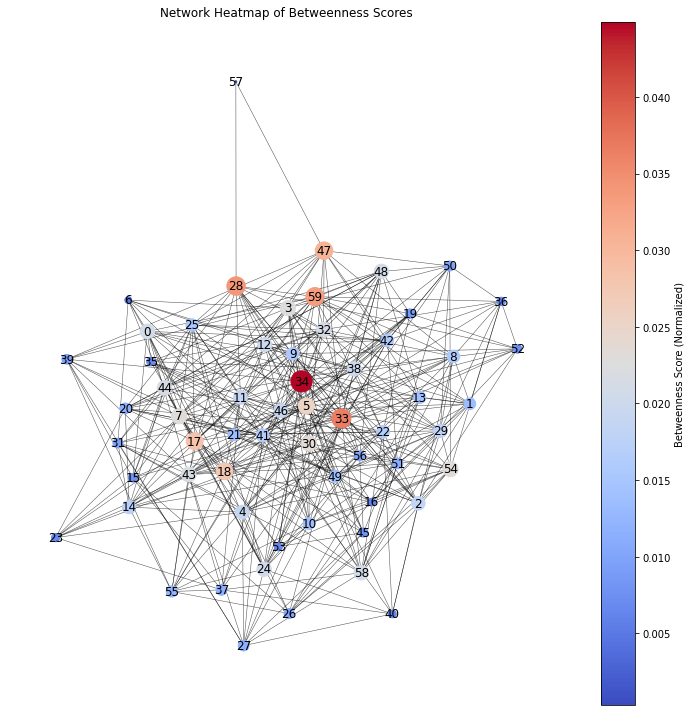

In [156]:

# Assuming np_adjacency_remove_self_random is your adjacency matrix with self-loops removed and random weights
# Assuming centrality_dict_self_removed_random_normalized is your dictionary of normalized centrality scores for nodes

G1 = nx.from_numpy_array(np_adjacency_remove_self_random)
pos = nx.spring_layout(G1)  # Use spring layout for node positioning

# Extract node values for heatmap
node_values = [betweenness_centralities_normalized[v] for v in G1.nodes()] 

# Create the heatmap
plt.figure(figsize=(10, 10))

# Choose a colormap (options: 'viridis', 'plasma', 'coolwarm', etc.)
cmap = cm.coolwarm  # Choose a colormap that suits your needs

# Create the node size list with scaling
node_size = [v * 10000 for v in node_values]  # Adjust scaling factor as needed


# Draw the graph with heatmap
nx.draw_networkx_nodes(G1, pos, nodelist=G1.nodes(), node_color=node_values, cmap=cmap, node_size=node_size)
nx.draw_networkx_edges(G1, pos, alpha=0.7, width=0.5)

# Add labels to nodes (optional)
nx.draw_networkx_labels(G1, pos)

# Create a custom legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(node_values), vmax=max(node_values)))
sm.set_array([])
plt.colorbar(sm, label='Betweenness Score (Normalized)')

plt.title('Network Heatmap of Betweenness Scores')
plt.axis('off')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Betweenness Scores')

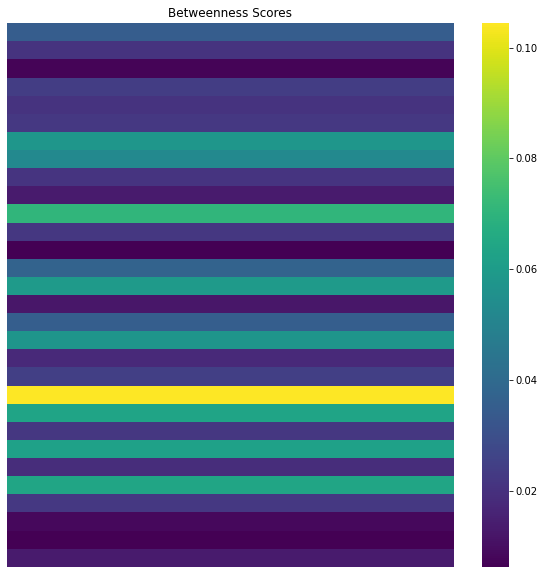

In [383]:
#heat_map of the betweenness scores
betweenness_df = pd.DataFrame(betweenness_centralities_normalized.items(), columns=['Vertex', 'Betweenness Score'])
betweenness_df = betweenness_df.sort_values(by='Vertex')
betweenness_df = betweenness_df.reset_index(drop=True)

betweenness_matrix = np.zeros((30, 30))
for i in range(30):
    betweenness_matrix[i] = betweenness_df['Betweenness Score'][i]

plt.figure(figsize=(10, 10))
sns.heatmap(betweenness_matrix, cmap='viridis', annot=False, fmt='.2f', xticklabels=False, yticklabels=False)
plt.title('Betweenness Scores')

In [384]:
with open('betweenness_dict_self_removed_random_normalised_30cross30_inverted_muscle_no_exponent.json', 'w') as f:
    json.dump(betweenness_centralities_normalized, f)

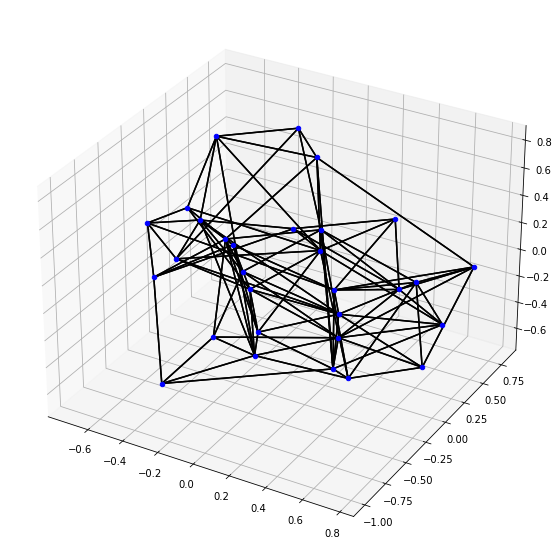

In [385]:
#can you neatly plot the graph in a 3-D fashion, with the help of the adjacency matrix given 
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

G = nx.from_numpy_array(np_adjacency_remove_self_random)
pos = nx.spring_layout(G, dim=3)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
for i in range(30):
    ax.scatter(pos[i][0], pos[i][1], pos[i][2], color='blue')
for i in range(30):
    for j in range(30):
        if np_adjacency_remove_self_random[i][j] > 0:
            ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], [pos[i][2], pos[j][2]], color='black')
plt.show()

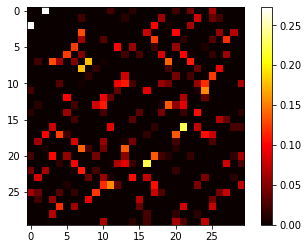

In [386]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have your adjacency matrix as np_adjacency_remove_self_random

plt.imshow(np_adjacency_remove_self_random, cmap='hot')
plt.colorbar()
plt.show()

In [387]:
G = nx.from_numpy_array(np_adjacency_remove_self_random)
pos = nx.circular_layout(G)  # Or any other layout function
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=2.0 * np_adjacency_remove_self_random)

# Save the graph as an image
plt.savefig("my_graph.png")  # Replace with your desired filename



ValueError: object too deep for desired array

ValueError: object too deep for desired array

<Figure size 432x288 with 1 Axes>

In [ ]:
def make_absorbing_state(transition_matrix, absorbing_index):
    """
    Modifies the transition matrix to treat a vertex as an absorbing state.

    Parameters:
        transition_matrix (np.ndarray): Original transition matrix (n x n).
        absorbing_index (int): Index of the vertex to be treated as absorbing.

    Returns:
        np.ndarray: Modified transition matrix with absorbing state.
    """
    modified_matrix = transition_matrix.copy()
    n = modified_matrix.shape[0]
    modified_matrix[absorbing_index] = np.zeros(n)  # Set row to 0
    modified_matrix[absorbing_index, absorbing_index] = 1  # Self-loop
    return modified_matrix

def stationary_distribution_fixed(modified_matrix, absorbing_index):
    """
    Computes the stationary distribution of a Markov chain with an absorbing state.

    Parameters:
        modified_matrix (np.ndarray): Transition matrix with absorbing state.
        absorbing_index (int): Index of the absorbing state.

    Returns:
        np.ndarray: Stationary distribution (n elements).
    """
    n = modified_matrix.shape[0]
    
    # Transition matrix for transient states
    Q = np.delete(np.delete(modified_matrix, absorbing_index, axis=0), absorbing_index, axis=1)
    I = np.eye(Q.shape[0])
    N = np.linalg.inv(I - Q)  # Fundamental matrix

    # Absorbing state probability
    transient_probs = N.sum(axis=1)  # Row sums give stationary probabilities
    transient_probs /= transient_probs.sum()  # Normalize to make them probabilities

    # Insert absorbing state's probability back
    full_distribution = np.zeros(n)
    full_distribution[:absorbing_index] = transient_probs[:absorbing_index]
    full_distribution[absorbing_index + 1:] = transient_probs[absorbing_index:]
    full_distribution[absorbing_index] = 1.0  # Absorbing state probability is 1
    return full_distribution

# Example usage
absorbing_index = 2  # Treat vertex 2 as absorbing
modified_matrix = make_absorbing_state(P, absorbing_index)
stationary_probs_fixed = stationary_distribution_fixed(modified_matrix, absorbing_index)

print("Fixed Stationary Distribution:")
print(stationary_probs_fixed)
stationary_probs_fixed.shape
# Exclude the absorbing state's probability
transient_sum = stationary_probs_fixed[np.arange(len(stationary_probs_fixed)) != absorbing_index].sum()
print("Sum of transient states' probabilities:", transient_sum)  # Should be 1.0

print("Sum of Probabilities:", stationary_probs_fixed.sum())


Fixed Stationary Distribution:
[0.0431898  0.0419044  1.         0.05527635 0.05507637 0.05501247
 0.04936958 0.05320497 0.05403064 0.05423106 0.05588489 0.05472016
 0.05316203 0.054342   0.0531463  0.05305935 0.05173074 0.05085916
 0.05574271 0.05605701]
Sum of transient states' probabilities: 0.9999999999999999
Sum of Probabilities: 1.9999999999999998


In [ ]:
test_subset

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.000000,0.432041,0.272557,0.098909,0.018232,0.011923,0.093101,0.038028,0.058098,0.092161,0.038864,0.023866,0.025390,0.020032,0.012036,0.078095,0.097690,0.039188,0.044234,0.017150
1,0.432041,1.000000,0.342903,0.004179,0.051786,0.014808,0.042831,0.022655,0.005277,0.128427,0.010790,0.010568,0.082468,0.011971,0.062310,0.046428,0.115219,0.140294,0.060292,0.038590
2,0.272557,0.342903,1.000000,0.017849,0.020318,0.028319,0.167359,0.091176,0.040928,0.013952,0.014744,0.038833,0.064493,0.049119,0.060853,0.057304,0.082274,0.099370,0.001713,0.005675
3,0.098909,0.004179,0.017849,1.000000,0.070137,0.083361,0.015539,0.130609,0.050626,0.001643,0.018128,0.102219,0.070757,0.144252,0.001772,0.038903,0.078035,0.060917,0.079788,0.097062
4,0.018232,0.051786,0.020318,0.070137,1.000000,0.005056,0.004922,0.061846,0.116720,0.062122,0.030268,0.028914,0.157331,0.032597,0.156783,0.100527,0.058689,0.124409,0.143623,0.030289
5,0.011923,0.014808,0.028319,0.083361,0.005056,1.000000,0.122589,0.008213,0.193714,0.112486,0.008092,0.220664,0.101056,0.041076,0.060318,0.073048,0.131402,0.020334,0.020805,0.065851
6,0.093101,0.042831,0.167359,0.015539,0.004922,0.122589,1.000000,0.047745,0.200115,0.080126,0.016757,0.116005,0.118221,0.023386,0.133603,0.024138,0.002304,0.151943,0.084904,0.019710
7,0.038028,0.022655,0.091176,0.130609,0.061846,0.008213,0.047745,1.000000,0.177060,0.085009,0.004513,0.156198,0.074503,0.078594,0.090125,0.092894,0.110616,0.032793,0.132183,0.139604
8,0.058098,0.005277,0.040928,0.050626,0.116720,0.193714,0.200115,0.177060,1.000000,0.015463,0.012818,0.052325,0.071307,0.109483,0.012355,0.114056,0.057717,0.025578,0.006356,0.024341
9,0.092161,0.128427,0.013952,0.001643,0.062122,0.112486,0.080126,0.085009,0.015463,1.000000,0.010261,0.125204,0.097819,0.080719,0.069553,0.030755,0.059356,0.010593,0.141503,0.044367


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np

# Assuming your adjacency matrix is stored as a DataFrame called 'test_subset'

# Convert the adjacency matrix to a NetworkX graph (weighted graph)
test_subsetcopy = test_subset.copy()

# Create a graph from the adjacency matrix DataFrame (assuming 'df' is your adjacency matrix)
test_subsetcopy.columns = range(len(test_subsetcopy.columns))  # Ensure column names are integers
test_subsetcopy.index = range(len(test_subsetcopy.index))  # Ensure row names are integers
G = nx.from_pandas_adjacency(test_subsetcopy, create_using=nx.DiGraph)

# Add capacities to the edges (if not already set)
for u, v, data in G.edges(data=True):
    if 'capacity' not in data:
        data['capacity'] = 1000  # Default capacity if not already set

# Initialize the MinCutDict for storing the fractions between source, sink and the other nodes
MinCutDict = {}

# Function to compute the mincut between two nodes in the graph
def compute_mincut(graph, source, sink):
    # Compute the mincut using networkx
    cut_value, partition = nx.minimum_cut(graph, source, sink)
    reachable, non_reachable = partition

    # Get the edges that form the mincut
    mincut_edges = []
    for u in reachable:
        for v in graph.neighbors(u):
            if v in non_reachable:
                mincut_edges.append((u, v))

    return mincut_edges

# Loop through all pairs of nodes to compute mincut and update MinCutDict
for source in G.nodes():
    for sink in G.nodes():
        if source != sink:
            # Compute the mincut for the pair
            mincut_edges = compute_mincut(G, source, sink)

            # Calculate the number of mincut edges (excluding source and sink)
            N = len(mincut_edges)

            # If there are mincut edges, proceed
            if N > 0:
                # Initialize the dictionary for this (source, sink) pair
                if (source, sink) not in MinCutDict:
                    MinCutDict[(source, sink)] = {node: 0.0 for node in G.nodes() if node != source and node != sink}

                # Distribute the fraction of mincut edges among the nodes involved in the cut
                for u, v in mincut_edges:
                    for node in [u, v]:
                        if node != source and node != sink:
                            MinCutDict[(source, sink)][node] += 1 / N

# Print the MinCutDict
print("MinCutDict:")
for key, value in MinCutDict.items():
    print(f"Source: {key[0]}, Sink: {key[1]} -> {value}")


MinCutDict:
Source: 0, Sink: 1 -> {2: 0.034482758620689655, 3: 0.034482758620689655, 4: 0.034482758620689655, 5: 0.034482758620689655, 6: 0.034482758620689655, 7: 0.034482758620689655, 8: 0.034482758620689655, 9: 0.034482758620689655, 10: 0.034482758620689655, 11: 0.034482758620689655, 12: 0.034482758620689655, 13: 0.034482758620689655, 14: 0.034482758620689655, 15: 0.034482758620689655, 16: 0.034482758620689655, 17: 0.034482758620689655, 18: 0.034482758620689655, 19: 0.034482758620689655, 20: 0.034482758620689655, 21: 0.034482758620689655, 22: 0.034482758620689655, 23: 0.034482758620689655, 24: 0.034482758620689655, 25: 0.034482758620689655, 26: 0.034482758620689655, 27: 0.034482758620689655, 28: 0.034482758620689655, 29: 0.034482758620689655}
Source: 0, Sink: 2 -> {1: 0.034482758620689655, 3: 0.034482758620689655, 4: 0.034482758620689655, 5: 0.034482758620689655, 6: 0.034482758620689655, 7: 0.034482758620689655, 8: 0.034482758620689655, 9: 0.034482758620689655, 10: 0.0344827586206896

In [ ]:
import numpy as np

def random_walk_centrality_weighted(A, source, sink, normalize="sum"):
    # Step 1: Create the weighted degree matrix D
    degree_matrix = np.sum(A, axis=1)  # Sum of each row (weighted degree of each vertex)
    D = np.diag(degree_matrix)  # Degree matrix as a diagonal matrix
    
    # Step 2: Calculate the transition matrix M = A * D^-1
    D_inv = np.linalg.inv(D)  # Inverse of the degree matrix
    M = np.dot(A, D_inv)  # Transition matrix
    
    # Step 3: Remove the sink row and column from M to get M_t
    M_t = np.delete(M, sink, axis=0)  # Remove sink row
    M_t = np.delete(M_t, sink, axis=1)  # Remove sink column
    
    # Step 4: Compute the fundamental matrix N = (I - M_t)^-1
    I = np.eye(M_t.shape[0])  # Identity matrix of the same size as M_t
    N = np.linalg.inv(I - M_t)  # Fundamental matrix
    
    # Step 5: Get the random walk centrality for each vertex
    centrality = np.sum(N, axis=0)  # Sum of visits to each vertex
    
    # Normalize the centrality values
    if normalize == "minmax":
        min_centrality = np.min(centrality)
        max_centrality = np.max(centrality)
        centrality_normalized = (centrality - min_centrality) / (max_centrality - min_centrality)
    elif normalize == "sum":
        centrality_normalized = centrality / np.sum(centrality)
    else:
        raise ValueError("Normalization method must be either 'minmax' or 'sum'.")
    
    return centrality_normalized

# Example Usage
# A = Weighted adjacency matrix for the graph
# Example graph: 5 nodes, source = 0, sink = 4
A = test_subsetcopy.values

source = 0  # Source node
sink = 4    # Sink node

# Compute random walk centrality for the weighted graph with sum normalization
centrality_normalized = random_walk_centrality_weighted(A, source, sink, normalize="sum")
print("Normalized Random Walk Centrality (Sum Normalized):", centrality_normalized)

# Compute random walk centrality for the weighted graph with min-max normalization
centrality_normalized_minmax = random_walk_centrality_weighted(A, source, sink, normalize="minmax")
print("Normalized Random Walk Centrality (Min-Max Normalized):", centrality_normalized_minmax)


Normalized Random Walk Centrality (Sum Normalized): [0.03538388 0.03486885 0.03539341 0.03431552 0.03537929 0.03529031
 0.03441865 0.03396534 0.03441428 0.0350986  0.0352548  0.03312252
 0.03497025 0.03267589 0.03394527 0.03487446 0.03361201 0.03257752
 0.03490898 0.03566151 0.0351923  0.03404441 0.03369977 0.03560022
 0.03503505 0.03388939 0.03371277 0.03400563 0.03468913]
Normalized Random Walk Centrality (Min-Max Normalized): [0.90997831 0.74297775 0.91306786 0.5635577  0.90848847 0.87963629
 0.59699783 0.45000748 0.59557887 0.81747472 0.8681227  0.17672039
 0.77585786 0.03189752 0.44350166 0.74479551 0.33544123 0.
 0.75598786 1.         0.8478579  0.47564922 0.36389665 0.98012862
 0.79686812 0.42538152 0.36811016 0.46307239 0.68470099]


In [ ]:

import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Step 1: Use the test_subset graph for visualization
adj_matrix = test_subset.to_numpy()  # Assuming we are using the smaller subset
G = nx.from_numpy_array(adj_matrix)

In [ ]:
G

In [ ]:
len(centrality_normalized)

29

In [ ]:
# Step 2: Calculate random walk centrality using the earlier defined function
# Assuming `A` is your adjacency matrix
source = 0  # Define the source
sink = 4    # Define the sink

# Step 3: Node size and edge width based on centrality and weights
node_sizes = [500 + 5000 * centrality_normalized[node] for node in G.nodes]
edge_widths = [1 + 10 * G[u][v]['weight'] for u, v in G.edges]

IndexError: index 29 is out of bounds for axis 0 with size 29

In [ ]:





# Step 4a: Plot the graph with weighted edges (basic layout)
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # Spring layout for better visualization
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    node_color="skyblue",
    edge_color="gray",
    width=edge_widths,
    font_size=8
)
plt.title("Graph Visualization with Weighted Edges")
plt.show()

# Step 4b: Plot with node centrality (using normalized random walk centrality)
plt.figure(figsize=(10, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=list(centrality_normalized.values()),  # Color by normalized centrality
    cmap=plt.cm.plasma,  # Apply the color map
    edge_color="gray",
    width=2,
    font_size=8
)
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.plasma), label="Random Walk Centrality")
plt.title("Graph Visualization with Normalized Random Walk Centrality")
plt.show()


IndexError: index 29 is out of bounds for axis 0 with size 29